## Tarea clasificación
### Materia: Laboratorio de Aprendizaje Estádistico 
### Profesor: Antonio Manguart Paez
### Alumna: Maria Fernanda Gómez Flores


## Instrucciones

Convertir el precio de las casas a clasificación:

- 1 si la casa vale mas de $250,000
- 0 si la casa vale $250,000 o menos

Crear los modelos:
- KNN
- Regresión logística
- Polinomial
- Ridge
- LDA

Obtener el AUC de cada modelo y encontrar el mejor

Realizar calibración


## Preparación de datos


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
import numpy as np


In [2]:
df = pd.read_csv('../Data/housing.csv')


In [3]:
df.isna().mean()


longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        0.010029
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

In [4]:
df = df.fillna(df.mean(numeric_only=True))


In [5]:
df.isna().mean()


longitude             0.0
latitude              0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        0.0
population            0.0
households            0.0
median_income         0.0
median_house_value    0.0
ocean_proximity       0.0
dtype: float64

In [6]:
df


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


## Target


In [7]:
df['target'] = df['median_house_value'] > 250000


In [8]:
df.target.mean()


np.float64(0.2801356589147287)

El target queda en True cuando la casa vale mas de 250000 y False cuando vale 250000 o menos


In [9]:
X = df.drop(columns=['median_house_value','target','ocean_proximity'])
y = df['target']


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)


## Regresión Logística


In [11]:
model_logistica=linear_model.LogisticRegression()
model_logistica.fit(X_train,y_train)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [12]:
probabilidades_logistica=model_logistica.predict_proba(X_test)[:,1]
probabilidades_logistica


array([0.15073826, 0.73316687, 0.13459493, ..., 0.96369332, 0.02897499,
       0.28552693])

In [13]:
from sklearn.metrics import roc_auc_score

auc_logistica=roc_auc_score(y_true=y_test, y_score=probabilidades_logistica)
auc_logistica


np.float64(0.8855619633593295)

In [14]:
from sklearn.metrics import roc_curve

fpr_logistica, tpr_logistica, thresholds = roc_curve(
    y_true=y_test,
    y_score=probabilidades_logistica
)


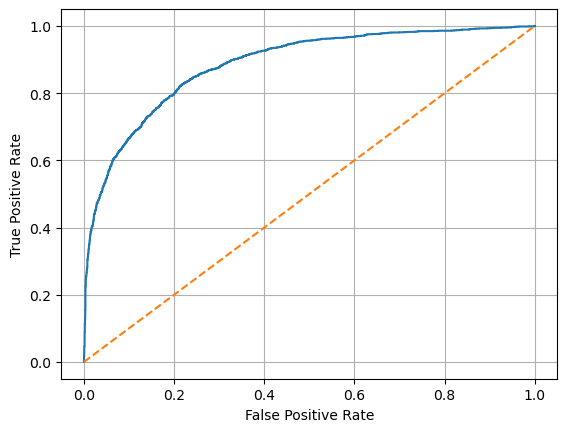

In [15]:
plt.plot(fpr_logistica,tpr_logistica)
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()


Conceptualmente: entre mas cerca este el AUC de 1 mejor separa las casas de mas de 250000 de las demas


## KNN


In [16]:
from sklearn.neighbors import KNeighborsClassifier


In [17]:
model_knn=KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train,y_train)


KNeighborsClassifier()

In [18]:
probabilidades_knn=model_knn.predict_proba(X_test)[:,1]
probabilidades_knn


array([0.2, 0.2, 0.4, ..., 0.8, 0.2, 0. ])

In [19]:
auc_knn=roc_auc_score(y_true=y_test, y_score=probabilidades_knn)
auc_knn


np.float64(0.762803131093555)

In [20]:
fpr_knn, tpr_knn, thresholds = roc_curve(
    y_true=y_test,
    y_score=probabilidades_knn
)


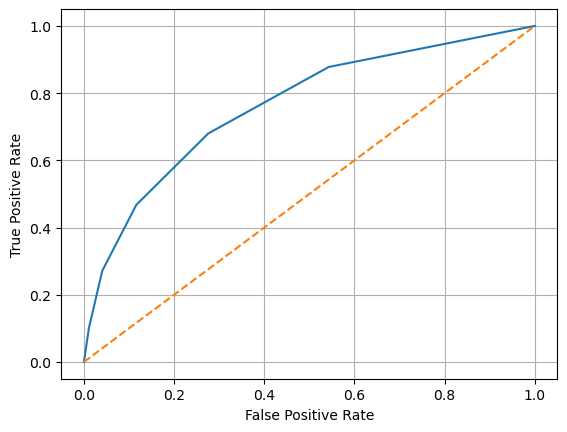

In [21]:
plt.plot(fpr_knn,tpr_knn)
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()


Conceptualmente: KNN clasifica usando los vecinos mas cercanos y el AUC me dice que tan bien logra separar las dos clases


## Polinomial


In [22]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV


In [23]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('scaler', StandardScaler()),
    ('model', linear_model.LogisticRegression())
])


In [24]:
params = {
    'poly__degree': [2]
}


In [25]:
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
    scoring='roc_auc',
    cv=5
)


In [26]:
grid.fit(X_train,y_train)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly', PolynomialFeatures()),
                                       ('scaler', StandardScaler()),
                                       ('model', LogisticRegression())]),
             param_grid={'poly__degree': [2]}, scoring='roc_auc')

In [27]:
grid.best_params_


{'poly__degree': 2}

In [28]:
probabilidades_poly=grid.predict_proba(X_test)[:,1]
probabilidades_poly


array([0.07443032, 0.52827125, 0.03486466, ..., 0.97338849, 0.00635805,
       0.47912223])

In [29]:
auc_poly=roc_auc_score(y_true=y_test, y_score=probabilidades_poly)
auc_poly


np.float64(0.9358365936532955)

In [30]:
fpr_poly, tpr_poly, thresholds = roc_curve(
    y_true=y_test,
    y_score=probabilidades_poly
)


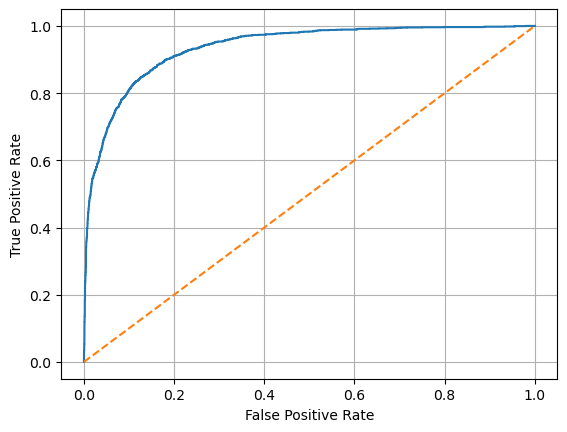

In [31]:
plt.plot(fpr_poly,tpr_poly)
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()


Conceptualmente: el polinomio agrega relaciones de grado 2 entre las variables para ver si logra separar mejor las casas


## Ridge


In [32]:
model_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', linear_model.LogisticRegression(penalty='l2'))
])


In [33]:
model_ridge.fit(X_train,y_train)


Pipeline(steps=[('scaler', StandardScaler()), ('model', LogisticRegression())])

In [34]:
probabilidades_ridge=model_ridge.predict_proba(X_test)[:,1]
probabilidades_ridge


array([0.128811  , 0.59216197, 0.06062788, ..., 0.94679167, 0.00431843,
       0.56750244])

In [35]:
auc_ridge=roc_auc_score(y_true=y_test, y_score=probabilidades_ridge)
auc_ridge


np.float64(0.9257802490829)

In [36]:
fpr_ridge, tpr_ridge, thresholds = roc_curve(
    y_true=y_test,
    y_score=probabilidades_ridge
)


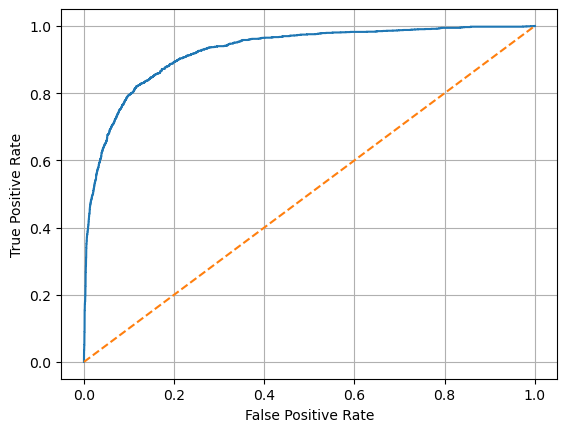

In [37]:
plt.plot(fpr_ridge,tpr_ridge)
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()


Conceptualmente: Ridge penaliza los coeficientes grandes para que el modelo no dependa demasiado de una variable


## LDA


In [38]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


In [39]:
model_lda=LinearDiscriminantAnalysis()
model_lda.fit(X_train,y_train)


LinearDiscriminantAnalysis()

In [40]:
probabilidades_lda=model_lda.predict_proba(X_test)[:,1]
probabilidades_lda


array([0.12120885, 0.53061932, 0.14276263, ..., 0.90838021, 0.01140788,
       0.51146611])

In [41]:
auc_lda=roc_auc_score(y_true=y_test, y_score=probabilidades_lda)
auc_lda


np.float64(0.9188394718133364)

In [42]:
fpr_lda, tpr_lda, thresholds = roc_curve(
    y_true=y_test,
    y_score=probabilidades_lda
)


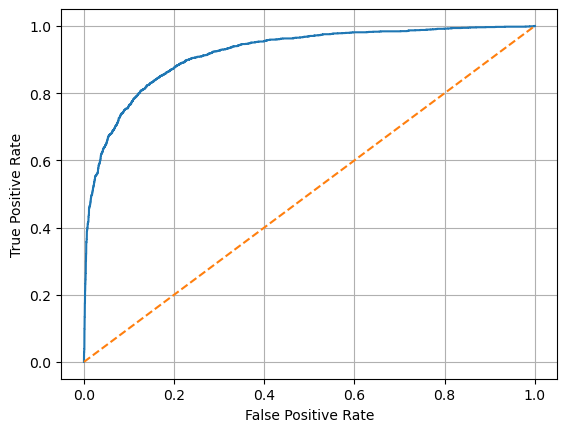

In [43]:
plt.plot(fpr_lda,tpr_lda)
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()


Conceptualmente: LDA busca separar las dos clases usando una combinación de las variables


## Comparación de Modelos y Resultados


In [44]:
modelos = ["Regresión Logística","KNN","Polinomial","Ridge","LDA"]

auc = [auc_logistica,auc_knn,auc_poly,auc_ridge,auc_lda]


In [45]:
resultados = pd.DataFrame({
    "Modelo": modelos,
    "AUC": auc
})


In [46]:
resultados = resultados.sort_values(by=["AUC"], ascending=[False])
resultados


,Modelo,AUC
2,Polinomial,0.935837
3,Ridge,0.925780
4,LDA,0.918839
0,Regresión Logística,0.885562
1,KNN,0.762803


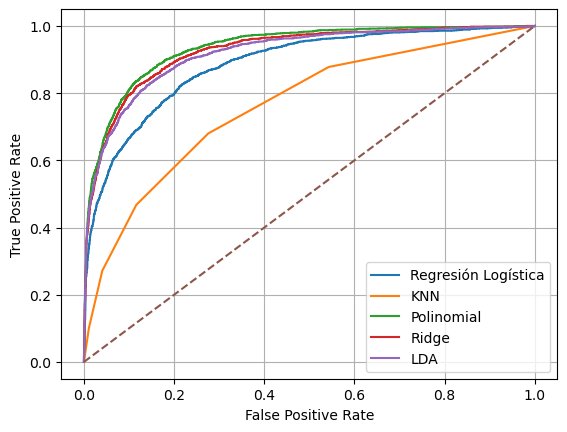

In [47]:
plt.plot(fpr_logistica,tpr_logistica,label="Regresión Logística")
plt.plot(fpr_knn,tpr_knn,label="KNN")
plt.plot(fpr_poly,tpr_poly,label="Polinomial")
plt.plot(fpr_ridge,tpr_ridge,label="Ridge")
plt.plot(fpr_lda,tpr_lda,label="LDA")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()


El mejor modelo es el que aparece primero en la tabla ya que cuenta con el AUC mas alto.  
Es el modelo que mejor logra separar las casas que valen mas de 250000 de las que valen 250000 o menos


## Calibracion


In [48]:
df_hist= pd.DataFrame({
    'y': y_test,
    'poly': grid.predict_proba(X_test)[:,1],
    'lineal': model_logistica.predict_proba(X_test)[:,1]
})


In [49]:
df_hist


,y,poly,lineal
14740,False,0.074430,0.150738
10101,False,0.528271,0.733167
20566,False,0.034865,0.134595
2670,False,0.003546,0.132473
15709,True,0.807283,0.443473
...,...,...,...
19681,False,0.005613,0.084132
12156,False,0.023076,0.059839
10211,True,0.973388,0.963693
2445,False,0.006358,0.028975


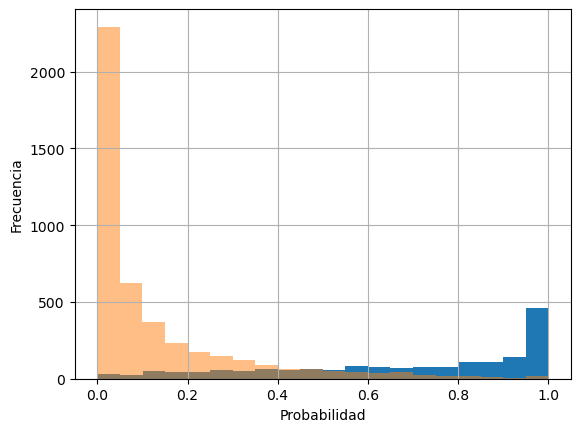

In [50]:
plt.hist(df_hist.query("y == 1").poly, bins=20)
plt.hist(df_hist.query("y == 0").poly, bins=20, alpha=.5)
plt.xlabel("Probabilidad")
plt.ylabel("Frecuencia")
plt.grid()


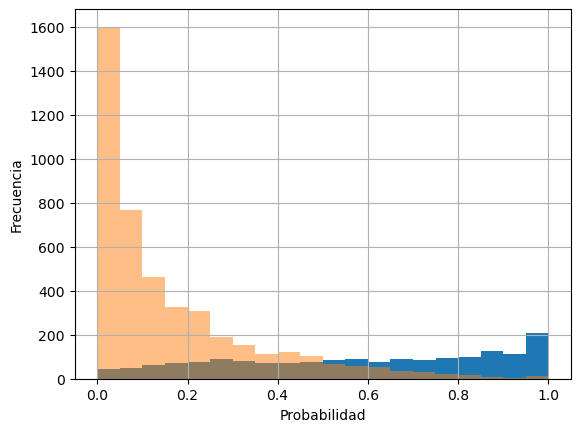

In [51]:
plt.hist(df_hist.query("y == 1").lineal, bins=20)
plt.hist(df_hist.query("y == 0").lineal, bins=20, alpha=.5)
plt.xlabel("Probabilidad")
plt.ylabel("Frecuencia")
plt.grid()


En la calibracion se pueden comparar las probabilidades que da el modelo para las casas que si son mayores a 250000 y las que no.  
Mientras mas separadas esten las probabilidades mas claro esta diferenciando las dos clases
